In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn import pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

import os
import random
import numpy as np

SEED = 42

# Fijamos todas las fuentes de aleatoriedad
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

sns.set_style("whitegrid")

# Cargar datos procesados desde el notebook 02
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Distribución y_train: {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}")
print(f"Distribución y_test:  {pd.Series(y_test).value_counts(normalize=True).round(3).to_dict()}")

X_train: (800, 38), X_test: (200, 38)
Distribución y_train: {0: 0.7, 1: 0.3}
Distribución y_test:  {0: 0.7, 1: 0.3}


In [13]:
def evaluar_modelo(modelo, X_train, y_train, X_test, y_test, nombre="Modelo"):
    """
    Entrena el modelo, evalúa en test y devuelve métricas + predicciones.
    """
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    for k, v in metricas.items():
        if k != "modelo":
            print(f"  {k:10s}: {v:.4f}")

    return metricas, y_pred, y_proba

In [14]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
m_dummy, _, _ = evaluar_modelo(
    dummy, X_train, y_train, X_test, y_test,
    "Baseline (siempre clase mayoritaria)"
)


  Baseline (siempre clase mayoritaria)
  accuracy  : 0.7000
  precision : 0.0000
  recall    : 0.0000
  f1        : 0.0000
  roc_auc   : 0.5000


c:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
m_lr, y_pred_lr, y_proba_lr = evaluar_modelo(
    lr, X_train, y_train, X_test, y_test, "Logistic Regression"
)


  Logistic Regression
  accuracy  : 0.7550
  precision : 0.5632
  recall    : 0.8167
  f1        : 0.6667
  roc_auc   : 0.8115


In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
m_rf, y_pred_rf, y_proba_rf = evaluar_modelo(
    rf, X_train, y_train, X_test, y_test, "Random Forest"
)


  Random Forest
  accuracy  : 0.7800
  precision : 0.6667
  recall    : 0.5333
  f1        : 0.5926
  roc_auc   : 0.8149


In [17]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
m_gb, y_pred_gb, y_proba_gb = evaluar_modelo(
    gb, X_train, y_train, X_test, y_test, "Gradient Boosting"
)


  Gradient Boosting
  accuracy  : 0.7950
  precision : 0.6863
  recall    : 0.5833
  f1        : 0.6306
  roc_auc   : 0.7886


In [18]:
modelos = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = []
for nombre, modelo in modelos.items():
    scores_auc = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    scores_f1 = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    scores_recall = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="recall", n_jobs=-1)

    resultados_cv.append({
        "modelo": nombre,
        "roc_auc_mean": scores_auc.mean(),
        "roc_auc_std": scores_auc.std(),
        "f1_mean": scores_f1.mean(),
        "f1_std": scores_f1.std(),
        "recall_mean": scores_recall.mean(),
        "recall_std": scores_recall.std(),
    })

cv_df = pd.DataFrame(resultados_cv).round(4)
print(cv_df.to_string(index=False))

             modelo  roc_auc_mean  roc_auc_std  f1_mean  f1_std  recall_mean  recall_std
Logistic Regression        0.7741       0.0409   0.5843  0.0361       0.6833      0.0580
      Random Forest        0.7933       0.0274   0.5418  0.0261       0.4750      0.0243
  Gradient Boosting        0.7884       0.0226   0.5077  0.0651       0.4417      0.0935


In [19]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

rf_base = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f"\nMejores hiperparámetros: {grid.best_params_}")
print(f"Mejor ROC-AUC en CV:     {grid.best_score_:.4f}")

rf_tuned = grid.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits



Mejores hiperparámetros: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Mejor ROC-AUC en CV:     0.8039


In [20]:
m_rf_tuned, y_pred_rf_tuned, y_proba_rf_tuned = evaluar_modelo(
    rf_tuned, X_train, y_train, X_test, y_test, "Random Forest (tuneado)"
)


  Random Forest (tuneado)
  accuracy  : 0.7650
  precision : 0.6140
  recall    : 0.5833
  f1        : 0.5983
  roc_auc   : 0.8087


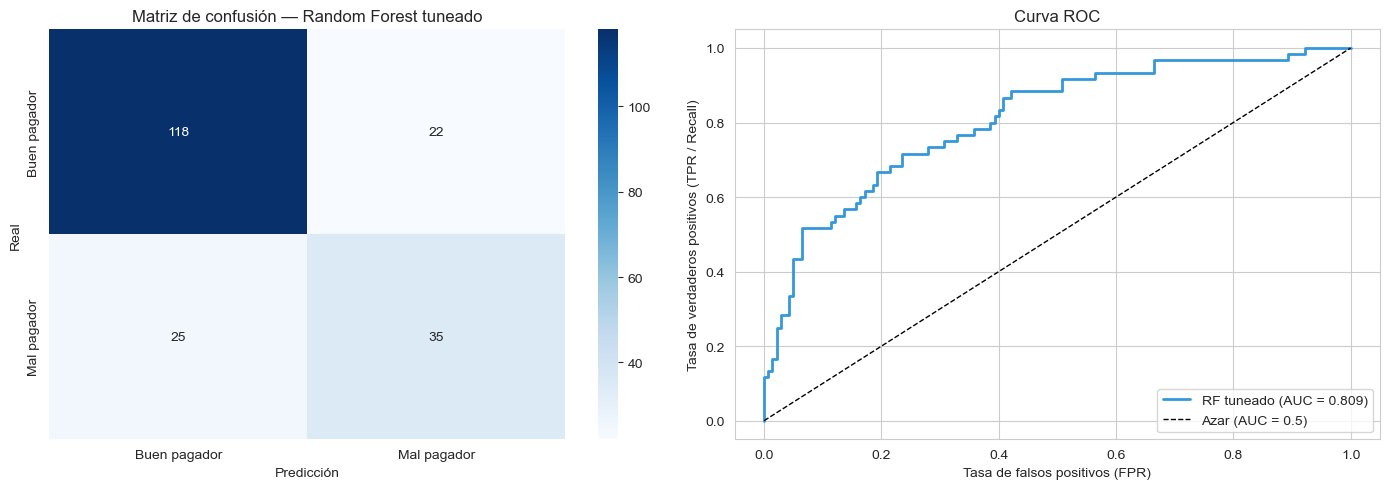


Interpretación de negocio de la matriz de confusión:
  Verdaderos negativos (buenos clasificados como buenos):    118
  Falsos positivos     (buenos clasificados como malos):    22  ← clientes perdidos injustamente
  Falsos negativos     (malos clasificados como buenos):    25  ← morosos que se cuelan (caros)
  Verdaderos positivos (malos clasificados como malos):     35

  Tasa de detección de malos pagadores: 58.33%
  Tasa de rechazo a buenos pagadores:   15.71%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_rf_tuned)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Buen pagador", "Mal pagador"],
    yticklabels=["Buen pagador", "Mal pagador"],
    ax=axes[0]
)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")
axes[0].set_title("Matriz de confusión — Random Forest tuneado")

fpr, tpr, _ = roc_curve(y_test, y_proba_rf_tuned)
auc = roc_auc_score(y_test, y_proba_rf_tuned)
axes[1].plot(fpr, tpr, color="#3498db", linewidth=2, label=f"RF tuneado (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Azar (AUC = 0.5)")
axes[1].set_xlabel("Tasa de falsos positivos (FPR)")
axes[1].set_ylabel("Tasa de verdaderos positivos (TPR / Recall)")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretación de negocio de la matriz de confusión:")
print(f"  Verdaderos negativos (buenos clasificados como buenos):    {tn}")
print(f"  Falsos positivos     (buenos clasificados como malos):    {fp}  ← clientes perdidos injustamente")
print(f"  Falsos negativos     (malos clasificados como buenos):    {fn}  ← morosos que se cuelan (caros)")
print(f"  Verdaderos positivos (malos clasificados como malos):     {tp}")
print(f"\n  Tasa de detección de malos pagadores: {tp/(tp+fn):.2%}")
print(f"  Tasa de rechazo a buenos pagadores:   {fp/(fp+tn):.2%}")

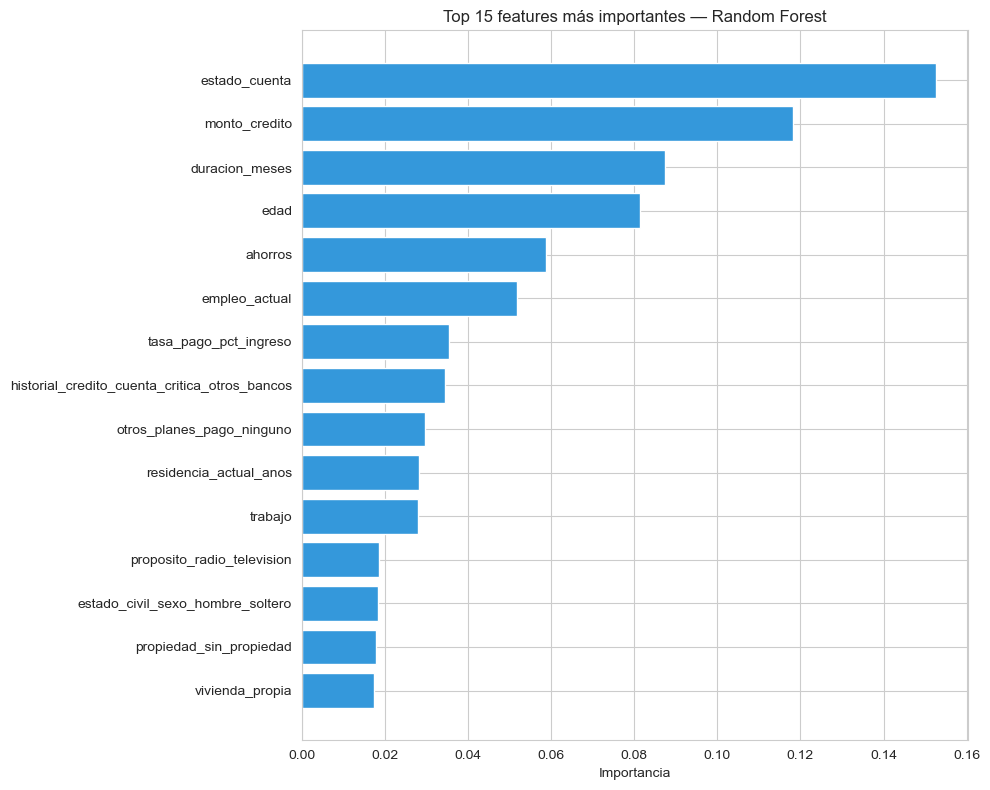


Top 10 features:
                                      feature  importancia
                                estado_cuenta     0.152608
                                monto_credito     0.118131
                               duracion_meses     0.087527
                                         edad     0.081431
                                      ahorros     0.058701
                                empleo_actual     0.051714
                        tasa_pago_pct_ingreso     0.035391
historial_credito_cuenta_critica_otros_bancos     0.034436
                    otros_planes_pago_ninguno     0.029748
                       residencia_actual_anos     0.028302


In [22]:
importancias = pd.DataFrame({
    "feature": X_train.columns,
    "importancia": rf_tuned.feature_importances_
}).sort_values("importancia", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top15 = importancias.head(15)
ax.barh(top15["feature"][::-1], top15["importancia"][::-1], color="#3498db")
ax.set_xlabel("Importancia")
ax.set_title("Top 15 features más importantes — Random Forest")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importancias.head(10).to_string(index=False))

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=SEED))
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "../data/processed/modelo_final.joblib")
print("Modelo guardado en data/processed/modelo_final.joblib")

Modelo guardado en data/processed/modelo_final.joblib
